# 01 — Data Preprocessing & Tokenizer (Task 1)

Builds both data pipelines end to end:
1. Hindi corpus -> deterministic train/val split -> SentencePiece BPE (vocab=5000) trained on train only.
2. Classification CSV -> label mapping (0/1/2) -> stratified train/val split.

All artifacts (splits, tokenizer, cached token tensors) are saved to `outputs/` so
notebooks 02-04 and the background training scripts can load them directly.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import (
    set_seed, get_device, CORPUS_DIR, CLS_CSV, SPLITS_DIR, TOKENIZER_DIR, FIG_DIR, SEED,
)
from src import data as data_mod
from src import tokenizer as tok_mod
from src import plots

set_seed(SEED)
plots.setup_style()
device = get_device()
print('Device:', device)

Device: cuda


## 1.1 Corpus ingestion + deterministic split

In [2]:
rows = data_mod.read_corpus(CORPUS_DIR, dedup=True)
print(f'Total usable documents: {len(rows):,}')

ids = [r['id'] for r in rows]
text_by_id = {r['id']: r['text'] for r in rows}

train_ids, val_ids = data_mod.split_ids(ids, val_ratio=0.1, seed=SEED, tag='lm')
assert len(train_ids & val_ids) == 0, 'leakage!'

train_texts = [text_by_id[i] for i in ids if i in train_ids]
val_texts = [text_by_id[i] for i in ids if i in val_ids]
print(f'Train docs: {len(train_texts):,} | Val docs: {len(val_texts):,}')

total_chars = sum(len(t) for t in train_texts) + sum(len(t) for t in val_texts)
print(f'Total characters: {total_chars:,}')

Reading Hindi corpus:   0%|          | 0/38308 [00:00<?, ?it/s]

Reading Hindi corpus:   1%|          | 457/38308 [00:00<00:08, 4565.79it/s]

Reading Hindi corpus:   2%|▏         | 953/38308 [00:00<00:07, 4789.65it/s]

Reading Hindi corpus:   4%|▍         | 1484/38308 [00:00<00:07, 5001.68it/s]

Reading Hindi corpus:   5%|▌         | 2003/38308 [00:00<00:07, 5075.10it/s]

...

Reading Hindi corpus:  93%|█████████▎| 35536/38308 [00:07<00:00, 6028.67it/s]

Reading Hindi corpus:  96%|█████████▌| 36831/38308 [00:07<00:00, 8045.78it/s]

Reading Hindi corpus: 100%|█████████▉| 38130/38308 [00:07<00:00, 9498.50it/s]

Reading Hindi corpus: 100%|██████████| 38308/38308 [00:07<00:00, 5255.21it/s]

Total usable documents: 33,520
Train docs: 30,168 | Val docs: 3,352
Total characters: 48,908,717


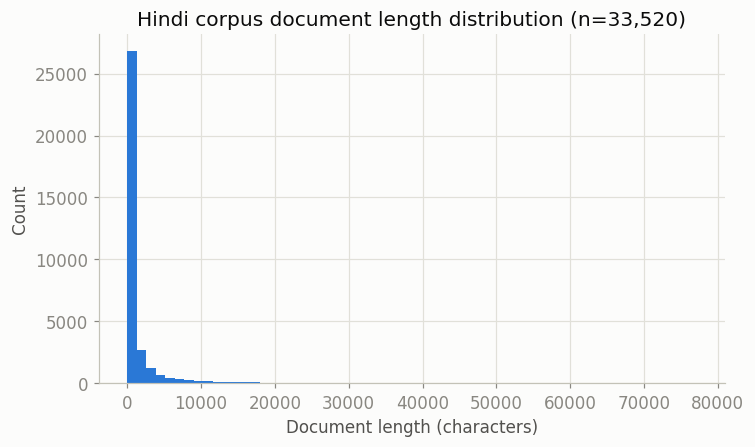

count    33520.000000
mean      1459.090603
std       4240.172295
min          1.000000
25%        107.000000
50%        231.000000
75%        917.250000
max      77103.000000
dtype: float64


In [3]:
# EDA: document length distribution (chars)
lengths = np.array([len(t) for t in train_texts + val_texts])
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.hist(lengths, bins=60, color=plots.CATEGORICAL[0])
ax.set_xlabel('Document length (characters)')
ax.set_ylabel('Count')
ax.set_title(f'Hindi corpus document length distribution (n={len(lengths):,})')
fig.tight_layout()
plots.savefig(fig, '01_corpus_doc_length_hist')
plt.show()
print(pd.Series(lengths).describe())

## 1.2 SentencePiece BPE tokenizer (vocab=5000, trained on train split only)

In [4]:
tok_mod.train_spm(train_texts, vocab_size=5000, model_type='bpe', character_coverage=0.9995)
sp = tok_mod.load_tokenizer()
print(f'Vocab size: {sp.vocab_size()}')
print(f'PAD={sp.pad_id()} UNK={sp.unk_id()} BOS={sp.bos_id()} EOS={sp.eos_id()}')

Vocab size: 5000
PAD=3 UNK=0 BOS=1 EOS=2


In [5]:
# Round-trip sanity check + subword examples
sample = train_texts[0][:200]
ids_sample = tok_mod.encode(sp, sample)
decoded = tok_mod.decode(sp, ids_sample)
print('Original :', sample)
print('Decoded  :', decoded)
print('Token IDs:', ids_sample[:20], '...')
print('Pieces   :', sp.encode(sample, out_type=str)[:20])

Original : ज़ागान, पश्चिमी पोलैंड में एक शहर है। यह शहर बोबर नदी के किनारे स्थित है। 2004 के जनगणना के अनुसार यहाँ की आबादी 26665 है। यह शहर ज़ागान प्रदेश की राजधानी है। अडोल्फ़ एन्ग्लेर रेंहोल्ड रोएहृच्त वोल्फग
Decoded  : ज़ागान, पश्चिमी पोलैंड में एक शहर है। यह शहर बोबर नदी के किनारे स्थित है। 2004 के जनगणना के अनुसार यहाँ की आबादी 26665 है। यह शहर ज़ागान प्रदेश की राजधानी है। अडोल्फ़ एन्ग्लेर रेंहोल्ड रोएहृच्त वोल्फग
Token IDs: [596, 174, 22, 4878, 1462, 8, 268, 767, 18, 54, 605, 10, 4872, 94, 605, 728, 363, 750, 11, 2819] ...
Pieces   : ['▁ज़', 'ाग', 'ान', ',', '▁पश्चिमी', '▁प', 'ोल', 'ैंड', '▁में', '▁एक', '▁शहर', '▁है', '।', '▁यह', '▁शहर', '▁बो', 'बर', '▁नदी', '▁के', '▁किनारे']


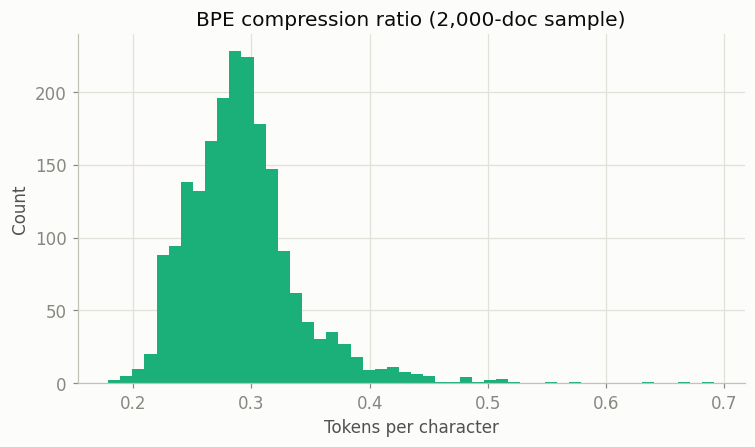

Mean tokens/char: 0.292  (i.e. ~3.42 chars/token)


In [6]:
# EDA: tokens-per-character compression ratio + a subword-length histogram
sample_docs = train_texts[:2000]
char_counts = [len(t) for t in sample_docs]
token_counts = [len(sp.encode(t, out_type=int)) for t in sample_docs]
compression = np.array(token_counts) / np.maximum(np.array(char_counts), 1)

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.hist(compression, bins=50, color=plots.CATEGORICAL[4])
ax.set_xlabel('Tokens per character')
ax.set_ylabel('Count')
ax.set_title('BPE compression ratio (2,000-doc sample)')
fig.tight_layout()
plots.savefig(fig, '01_tokenizer_compression_hist')
plt.show()
print(f'Mean tokens/char: {compression.mean():.3f}  (i.e. ~{1/compression.mean():.2f} chars/token)')

In [7]:
# Cache full tokenized train/val streams so scripts/train_lm.py doesn't re-tokenize 38k docs every run
from src.data import LMDataset

train_cache = SPLITS_DIR / 'lm_train_tokens.pt'
val_cache = SPLITS_DIR / 'lm_val_tokens.pt'

lm_train_ds = LMDataset(train_texts, sp, block_size=256, eos_id=sp.eos_id(), cache_path=train_cache)
lm_val_ds = LMDataset(val_texts, sp, block_size=256, eos_id=sp.eos_id(), cache_path=val_cache)

print(f'Train tokens: {len(lm_train_ds.tokens):,}')
print(f'Val tokens  : {len(lm_val_ds.tokens):,}')
print(f'Train (x,y) positions available: {len(lm_train_ds):,}')

Tokenizing LM split:   0%|          | 0/30168 [00:00<?, ?it/s]

Tokenizing LM split:   1%|          | 221/30168 [00:00<00:13, 2166.82it/s]

Tokenizing LM split:   2%|▏         | 459/30168 [00:00<00:12, 2290.13it/s]

Tokenizing LM split:   2%|▏         | 717/30168 [00:00<00:12, 2421.72it/s]

Tokenizing LM split:   3%|▎         | 960/30168 [00:00<00:12, 2288.94it/s]

...

Tokenizing LM split:  71%|███████   | 2384/3352 [00:01<00:00, 2685.27it/s]

Tokenizing LM split:  80%|███████▉  | 2667/3352 [00:01<00:00, 2718.18it/s]

Tokenizing LM split:  89%|████████▉ | 2996/3352 [00:01<00:00, 2783.91it/s]

Tokenizing LM split: 100%|██████████| 3352/3352 [00:01<00:00, 2603.62it/s]

Train tokens: 13,249,479
Val tokens  : 1,501,609
Train (x,y) positions available: 13,249,222


## 1.3 Classification preprocessing (labels -> 0/1/2, stratified split)

In [8]:
cls_df = data_mod.load_classification_df(CLS_CSV)
print(f'Rows: {len(cls_df)}')
print(cls_df['label_id'].value_counts().sort_index())

cls_train_df, cls_val_df = data_mod.stratified_cls_split(cls_df, val_ratio=0.2, seed=SEED)
cls_train_df.to_csv(SPLITS_DIR / 'cls_train.csv', index=False)
cls_val_df.to_csv(SPLITS_DIR / 'cls_val.csv', index=False)
print(f'Train: {len(cls_train_df)} | Val: {len(cls_val_df)}')

Rows: 717
label_id
0    240
1    204
2    273
Name: count, dtype: int64
Train: 573 | Val: 144


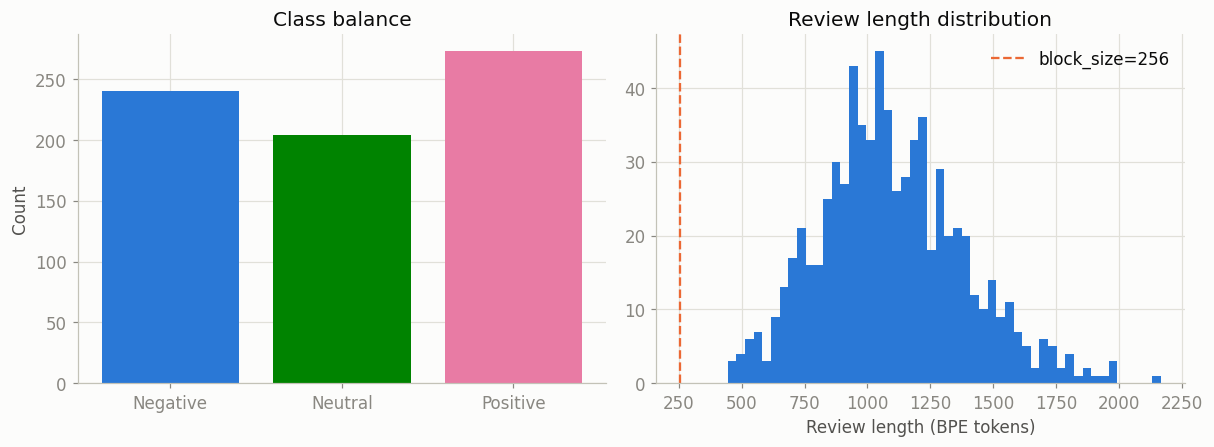

100.0% of reviews exceed block_size=256 tokens -> chunk/truncate handling required (see notebook 03).


In [9]:
# EDA: class balance + review length (chars & tokens) -- motivates the long-doc
# handling strategies (truncate / mean-pool / chunk-aggregate) explored in notebook 03.
label_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
counts = cls_df['label_id'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].bar([label_names[i] for i in counts.index], counts.values, color=plots.CATEGORICAL[:3])
axes[0].set_title('Class balance')
axes[0].set_ylabel('Count')

review_token_lens = [len(sp.encode(t, out_type=int)) for t in cls_df['text']]
axes[1].hist(review_token_lens, bins=50, color=plots.CATEGORICAL[0])
axes[1].axvline(256, color=plots.CATEGORICAL[5], linestyle='--', label='block_size=256')
axes[1].set_xlabel('Review length (BPE tokens)')
axes[1].set_title('Review length distribution')
axes[1].legend(frameon=False)
fig.tight_layout()
plots.savefig(fig, '01_classification_eda')
plt.show()

review_token_lens = np.array(review_token_lens)
pct_over_block = (review_token_lens > 256).mean() * 100
print(f'{pct_over_block:.1f}% of reviews exceed block_size=256 tokens -> chunk/truncate handling required (see notebook 03).')

## Summary

In [10]:
print('Artifacts written:')
print(f'  Tokenizer     : {TOKENIZER_DIR / "hindi_spm_bpe.model"}')
print(f'  LM splits     : {SPLITS_DIR}/lm_{{train,val}}_ids.txt')
print(f'  LM token cache: {train_cache.name}, {val_cache.name}')
print(f'  Cls splits    : {SPLITS_DIR}/cls_{{train,val}}.csv')
print(f'  Figures       : {FIG_DIR}')

Artifacts written:
  Tokenizer     : F:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3\outputs\tokenizer\hindi_spm_bpe.model
  LM splits     : F:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3\outputs\splits/lm_{train,val}_ids.txt
  LM token cache: lm_train_tokens.pt, lm_val_tokens.pt
  Cls splits    : F:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3\outputs\splits/cls_{train,val}.csv
  Figures       : F:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3\outputs\figures
